# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari Kaggle (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset?resource=download)

   Dataset ini digunakan untuk memprediksi kemungkinan seseorang mengalami stroke berdasarkan informasi kesehatan dan demografis pasien.

    Fitur dalam dataset:
    - gender
    - age
    - hypertension
    - heart_disease
    - ever_married
    - work_type
    - Residence_type
    - avg_glucose_level
    - bmi
    - smoking_status

    Target:
    - stroke
        - 0 = tidak stroke
        - 1 = stroke


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [21]:
df = pd.read_csv('stroke.csv')

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [23]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [24]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [25]:
df.duplicated().sum()

np.int64(0)

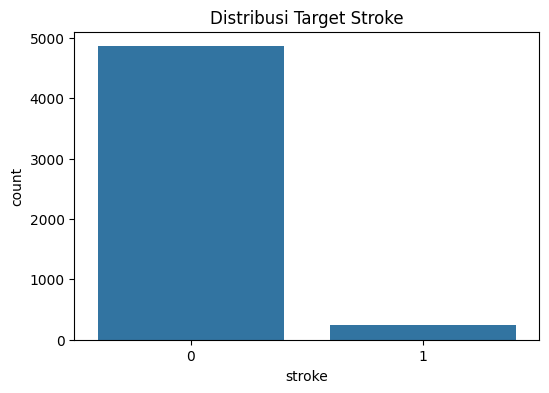

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x='stroke', data=df)

plt.title('Distribusi Target Stroke')

plt.show()

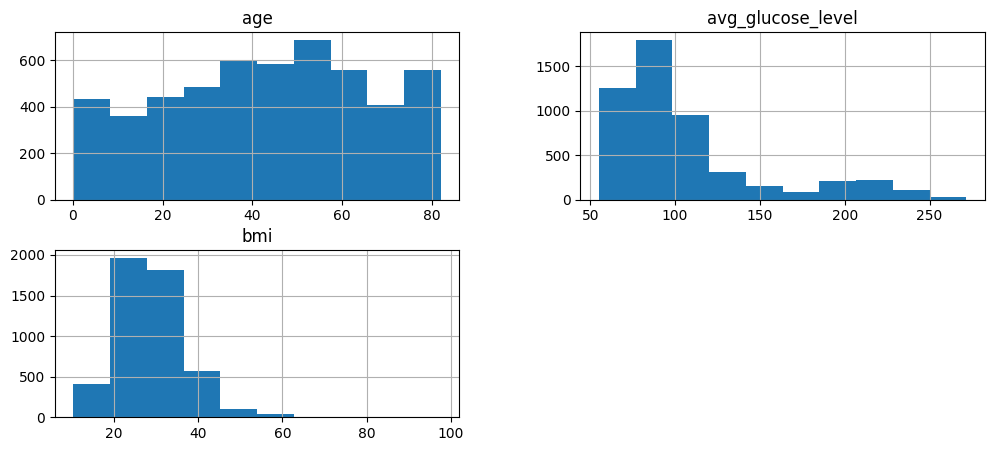

In [27]:
df[['age', 'avg_glucose_level', 'bmi']].hist(
    figsize=(12,5)
)

plt.show()

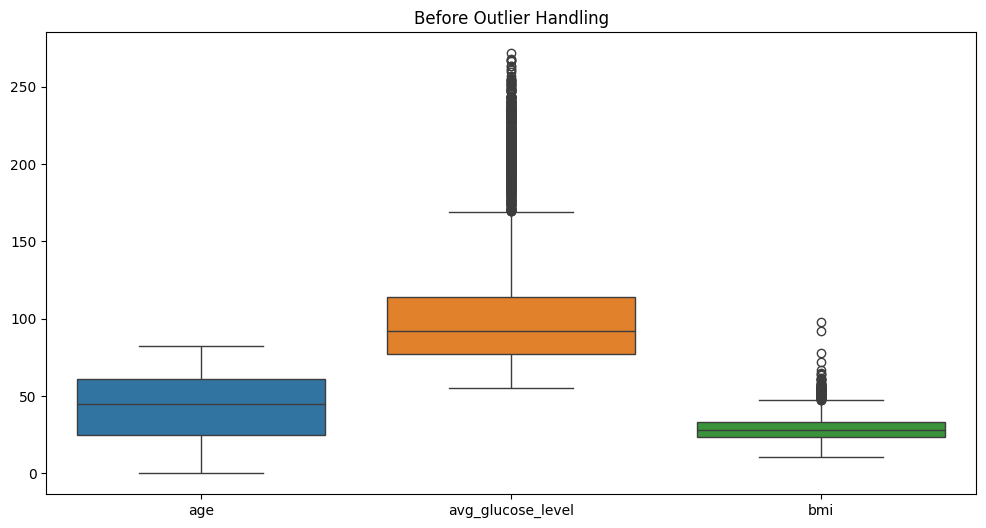

In [28]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[['age', 'avg_glucose_level', 'bmi']]
)

plt.title('Before Outlier Handling')

plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [29]:
original_shape = df.shape

print("Shape sebelum preprocessing:", original_shape)

Shape sebelum preprocessing: (5110, 12)


In [30]:
df.drop('id', axis=1, inplace=True)

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [31]:
df['bmi'].fillna(
    df['bmi'].median(),
    inplace=True
)

df.isnull().sum()

/tmp/ipykernel_1098/2138650384.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(


,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [11]:
df.drop_duplicates(inplace=True)

In [32]:
df.drop_duplicates(inplace=True)

print("Shape setelah remove duplicate:")
print(df.shape)

Shape setelah remove duplicate:
(5110, 11)


In [33]:
numeric_cols = [
    'age',
    'avg_glucose_level',
    'bmi'
]

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

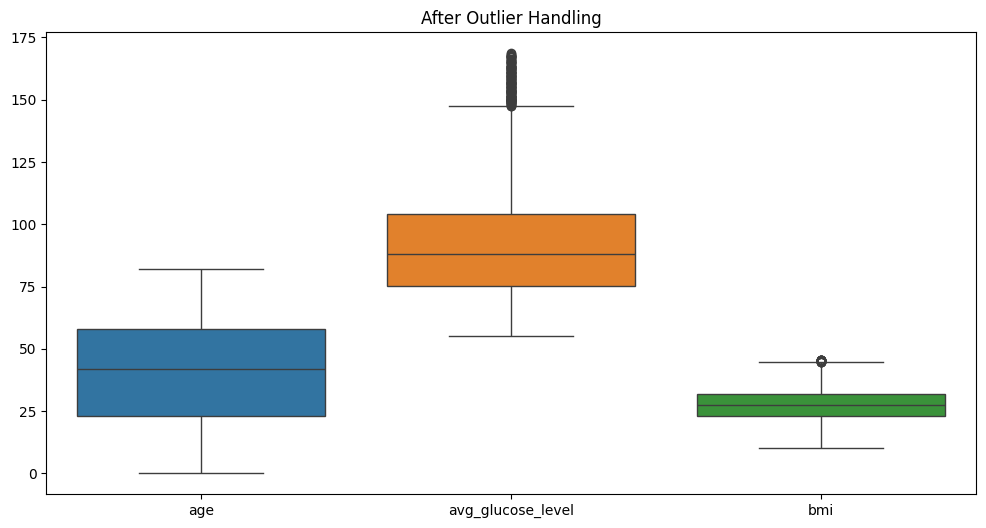

In [34]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[['age', 'avg_glucose_level', 'bmi']]
)

plt.title('After Outlier Handling')

plt.show()

In [35]:
bins = [0, 18, 40, 60, 100]

labels = [
    'Teen',
    'Adult',
    'Middle Age',
    'Senior'
]

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

df[['age', 'age_group']].head(10)

,age,age_group
2,80.0,Senior
6,74.0,Senior
7,69.0,Senior
8,59.0,Middle Age
9,78.0,Senior
10,81.0,Senior
11,61.0,Senior
12,54.0,Middle Age
15,50.0,Middle Age
18,60.0,Middle Age


In [36]:
categorical_cols = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status',
    'age_group'
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1,2
6,1,74.0,1,1,1,2,0,70.09,27.4,2,1,2
7,0,69.0,0,0,0,2,1,94.39,22.8,2,1,2
8,0,59.0,0,0,1,2,0,76.15,28.1,0,1,1
9,0,78.0,0,0,1,2,1,58.57,24.2,0,1,2


In [37]:
X = df.drop('stroke', axis=1)

y = df['stroke']

In [38]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [39]:
processed_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

processed_df['stroke'] = y.values

processed_df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,age_group,stroke
0,1.197351,1.733246,-0.283469,4.947985,0.778135,-0.181806,-1.015405,0.637398,0.729592,0.604481,0.596460,1
1,1.197351,1.467317,3.527717,4.947985,0.778135,-0.181806,-1.015405,-0.943755,-0.052882,0.604481,0.596460,1
2,-0.833605,1.245710,-0.283469,-0.202102,-1.285124,-0.181806,0.984829,0.128587,-0.758642,0.604481,0.596460,1
3,-0.833605,0.802495,-0.283469,-0.202102,0.778135,-0.181806,-1.015405,-0.676332,0.054517,-1.239249,-0.319226,1
4,-0.833605,1.644603,-0.283469,-0.202102,0.778135,-0.181806,0.984829,-1.452125,-0.543846,-1.239249,0.596460,1


In [40]:
print("Shape setelah preprocessing:")

print(processed_df.shape)

Shape setelah preprocessing:
(4383, 12)


In [41]:
processed_df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [42]:
processed_df.describe()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,age_group,stroke
count,4.383000e+03,4.383000e+03,4.383000e+03,4.383000e+03,4.383000e+03,4.383000e+03,4.383000e+03,4.383000e+03,4.383000e+03,4.383000e+03,4.383000e+03,4383.000000
mean,-7.943553e-17,2.269587e-16,-3.890720e-17,3.566493e-17,-9.726800e-17,9.726800e-18,-1.685979e-16,2.107473e-16,1.977783e-16,-6.484533e-18,-2.593813e-17,0.037417
std,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,1.000114e+00,0.189804
min,-8.336049e-01,-1.808926e+00,-2.834695e-01,-2.021025e-01,-1.285124e+00,-1.982606e+00,-1.015405e+00,-1.604371e+00,-2.676470e+00,-1.239249e+00,-1.234912e+00,0.000000
25%,-8.336049e-01,-7.930777e-01,-2.834695e-01,-2.021025e-01,-1.285124e+00,-1.818056e-01,-1.015405e+00,-7.237706e-01,-6.972719e-01,-1.239249e+00,-1.234912e+00,0.000000
50%,-8.336049e-01,4.903007e-02,-2.834695e-01,-2.021025e-01,7.781353e-01,-1.818056e-01,9.848287e-01,-1.516339e-01,-2.219657e-02,6.044808e-01,-3.192262e-01,0.000000
75%,1.197351e+00,7.581734e-01,-2.834695e-01,-2.021025e-01,7.781353e-01,7.185944e-01,9.848287e-01,5.537734e-01,6.221935e-01,6.044808e-01,5.964599e-01,0.000000
max,3.228307e+00,1.821888e+00,3.527717e+00,4.947985e+00,7.781353e-01,1.618994e+00,9.848287e-01,3.406955e+00,2.724133e+00,1.526345e+00,1.512146e+00,1.000000


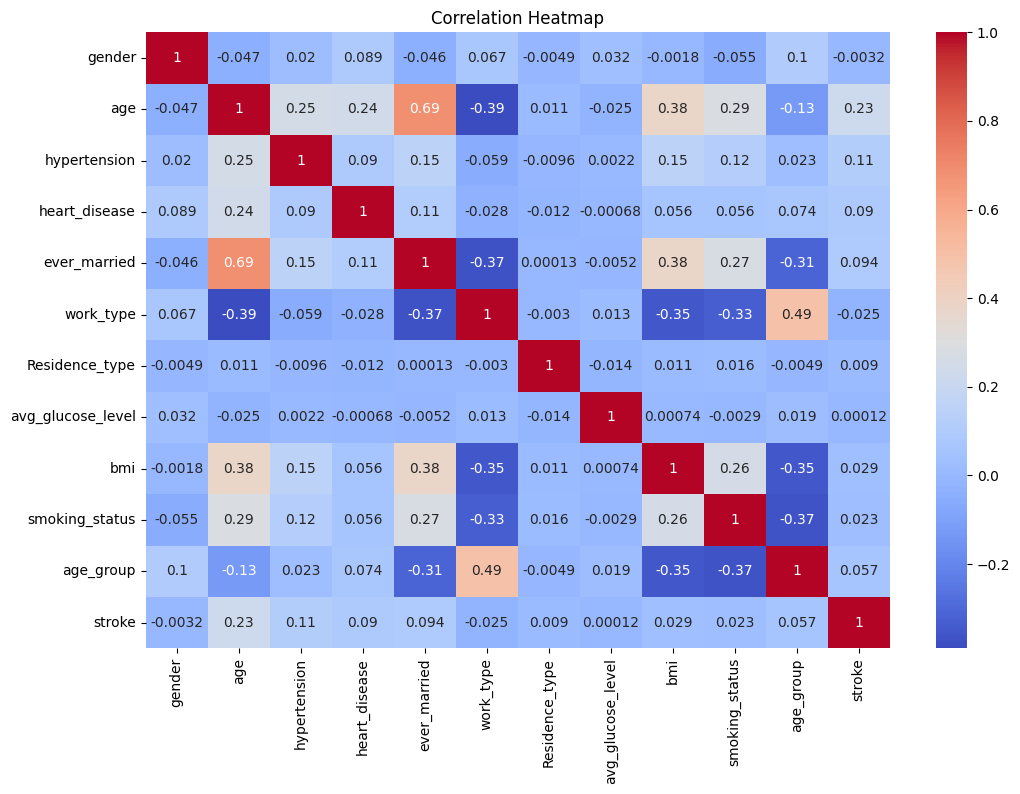

In [43]:
plt.figure(figsize=(12,8))

sns.heatmap(
    processed_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

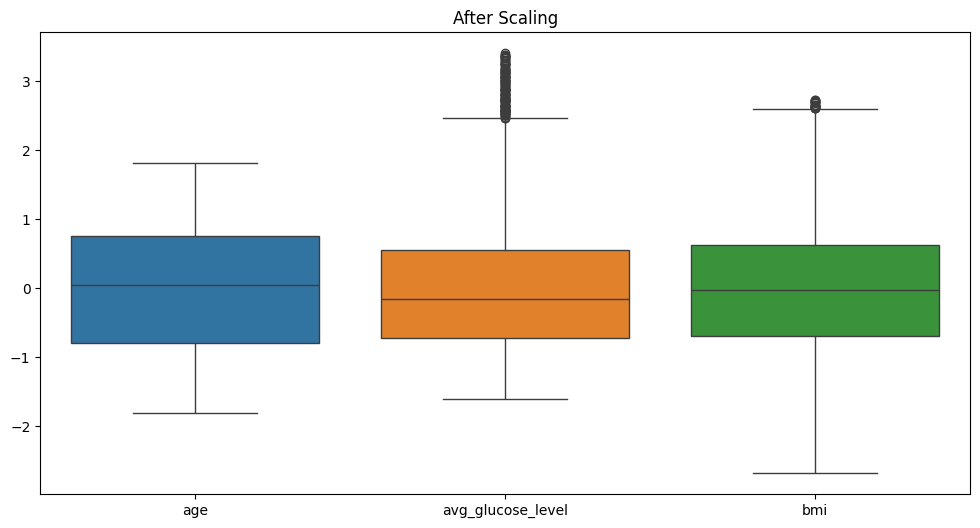

In [44]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=processed_df[
        ['age', 'avg_glucose_level', 'bmi']
    ]
)

plt.title('After Scaling')

plt.show()

In [45]:
processed_df.to_csv(
    'stroke_clean.csv',
    index=False
)

print("Dataset preprocessing berhasil disimpan!")

Dataset preprocessing berhasil disimpan!
